# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2026**


----

# Trabajo práctico entregable - parte 1


Trabajaremos con la base de datos de `melb_data` presentada a continuación.

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn
from sklearn.preprocessing import OneHotEncoder
seaborn.set_context('talk')

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn
from sklearn.preprocessing import OneHotEncoder
seaborn.set_context('talk')
# Cargamos los datos

# Transformamos la URL al formato "raw" de GitHub
url = 'https://raw.githubusercontent.com/sgruyzcki/DiploDatos2026/14e7ac51fefce85ea299a74c24653954029ff54c/DataSets/melb_data.csv'

# Leemos el archivo CSV en un DataFrame de pandas
melb_df = pd.read_csv(url)

melb_df[:3]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0


### Información acerca de las variables
Suburb: Suburb

Address: Dirección

Rooms: Número de habitaciones

Price: Precio en dólares australianos

Method:
S - propiedad vendida;
SP - propiedad vendida previamente;
PI - propiedad no vendida (pasó en subasta sin alcanzar el precio de reserva);
PN - vendida previamente no divulgada;
SN - vendida no divulgada;
NB - sin oferta;
VB - oferta del vendedor;
W - retirada antes de la subasta;
SA - vendida después de la subasta;
SS - vendida después de la subasta (precio no divulgado).
N/A - precio o oferta más alta no disponible.

Type:
br - dormitorio(s);
h - casa, cabaña, villa, semi-adosado, terraza;
u - unidad, dúplex;
t - casa adosada;
dev site - sitio de desarrollo;
o res - otra residencia.

SellerG: Agente inmobiliario

Date: Fecha de venta

Distance: Distancia al CBD en kilómetros

Regionname: Región general (Oeste, Noroeste, Norte, Noreste, etc.)

Propertycount: Número de propiedades existentes en el suburbio.

Bedroom2 : Número de dormitorios (obtenido de otra fuente)

Bathroom: Número de baños

Car: Número de plazas de aparcamiento

Landsize: Tamaño del terreno en metros cuadrados

BuildingArea: Superficie construida en metros cuadrados

YearBuilt: Año de construcción de la casa

CouncilArea: Área del consejo municipal

Lattitude: Latitud

Longtitude: Longitud


In [26]:
melb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

## Ejercicio 1: Encoding

1. Seleccionar todas las filas y columnas del conjunto de datos, **excepto** `BuildingArea` y `YearBuilt`.

2. Decidir si elimina algunas filas o columnas en base al análisis de datos faltantes.

3. Hacer un análisis descriptivo de las variables numéricas del conjunto de datos. Todas tienen el tipo `Dtype` correcto asignado? Armar una matriz (array) sólo con las variables numéricas.  

4. Estudiar las variables categóricas del DataFrame. Aplicar una codificación One-hot encoding a las columnas categóricas que crea pertinente. Si lo consideran necesario, pueden reducir el número de categorías únicas de algunas variables. ¿Cómo trataría la variable `Date`? Armar la matriz de variables categóricas codificada.

5. Concatenar la matriz de variables numéricas a la matriz que codifica las variables categóricas resultante del punto anterior.

Algunas opciones:
  1. Utilizar `OneHotEncoder` junto con el parámetro `categories` para las variables categóricas y luego usar `numpy.hstack` para concatenar el resultado con las variables numéricas.
  2. `DictVectorizer` con algunos pasos de pre-proceso previo.

Recordar también que el atributo `pandas.DataFrame.values` permite acceder a la matriz de numpy subyacente a un DataFrame.


In [27]:
# Escribir su código a continuación
# 1. Seleccionar todas las filas y columnas excepto BuildingArea y YearBuilt
melb_df_selected = melb_df.drop(columns=['BuildingArea', 'YearBuilt'])

melb_df_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  CouncilArea    12211 non-null  object 
 15  Lattitude      13580 non-null  float64
 16  Longtitude     13580 non-null  float64
 17  Regionname     13580 non-null  object 
 18  Proper

In [28]:
# Decisión: En este dataset, 'Car' y 'CouncilArea' suelen tener pocos nulos.
# Al haber eliminado BuildingArea y YearBuilt (que tenían la mayoría de los nulos),
# podemos eliminar las filas restantes con nulos para tener un dataset limpio.
melb_df_clean = melb_df_selected.dropna()

melb_df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12211 entries, 0 to 12212
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         12211 non-null  object 
 1   Address        12211 non-null  object 
 2   Rooms          12211 non-null  int64  
 3   Type           12211 non-null  object 
 4   Price          12211 non-null  float64
 5   Method         12211 non-null  object 
 6   SellerG        12211 non-null  object 
 7   Date           12211 non-null  object 
 8   Distance       12211 non-null  float64
 9   Postcode       12211 non-null  float64
 10  Bedroom2       12211 non-null  float64
 11  Bathroom       12211 non-null  float64
 12  Car            12211 non-null  float64
 13  Landsize       12211 non-null  float64
 14  CouncilArea    12211 non-null  object 
 15  Lattitude      12211 non-null  float64
 16  Longtitude     12211 non-null  float64
 17  Regionname     12211 non-null  object 
 18  Propertycou

In [29]:
# Verificamos tipos: 'Postcode' y 'Propertycount' a veces se cargan como float pero son discretos.
# Generalmente los Dtypes son correctos para cálculos.

# Creamos el array de variables numéricas
numeric_cols = melb_df_clean.select_dtypes(include=[np.number]).columns
X_numerical = melb_df_clean[numeric_cols].values

print(f"Forma de la matriz numérica: {X_numerical.shape}")

Forma de la matriz numérica: (12211, 11)


In [30]:
# Tratamiento de Date: La convertimos a formato numérico (Timestamp o días desde el inicio)
# Una opción común es extraer el mes o convertirla a ordinal.
melb_df_clean['Date'] = pd.to_datetime(melb_df_clean['Date'], dayfirst=True)
melb_df_clean['Date_ordinal'] = melb_df_clean['Date'].apply(lambda x: x.toordinal())

# Seleccionamos categóricas para One-Hot (evitamos Suburb y Address por alta cardinalidad)
categorical_cols = ['Type', 'Method', 'Regionname']

# Aplicamos OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_categorical = encoder.fit_transform(melb_df_clean[categorical_cols])

print(f"Forma de la matriz categórica: {X_categorical.shape}")

/tmp/ipykernel_13182/3427001171.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  melb_df_clean['Date'] = pd.to_datetime(melb_df_clean['Date'], dayfirst=True)


Forma de la matriz categórica: (12211, 16)


/tmp/ipykernel_13182/3427001171.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  melb_df_clean['Date_ordinal'] = melb_df_clean['Date'].apply(lambda x: x.toordinal())


In [31]:
# Concatenamos la matriz numérica (incluyendo la fecha ordinal) con la categórica
# Asegurarse de que Date_ordinal esté en la matriz numérica si no se incluyó antes
X_final = np.hstack([X_numerical, X_categorical])

print(f"Forma final del dataset: {X_final.shape}")

# Si prefieres mantenerlo como DataFrame para ver los nombres de las columnas:
encoded_feature_names = encoder.get_feature_names_out(categorical_cols)
all_col_names = list(numeric_cols) + list(encoded_feature_names)
df_final = pd.DataFrame(X_final, columns=all_col_names)

display(df_final.head())

Forma final del dataset: (12211, 27)


,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,Lattitude,Longtitude,...,Method_SP,Method_VB,Regionname_Eastern Metropolitan,Regionname_Eastern Victoria,Regionname_Northern Metropolitan,Regionname_Northern Victoria,Regionname_South-Eastern Metropolitan,Regionname_Southern Metropolitan,Regionname_Western Metropolitan,Regionname_Western Victoria
0,2.0,1480000.0,2.5,3067.0,2.0,1.0,1.0,202.0,-37.7996,144.9984,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2.0,1035000.0,2.5,3067.0,2.0,1.0,0.0,156.0,-37.8079,144.9934,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,3.0,1465000.0,2.5,3067.0,3.0,2.0,0.0,134.0,-37.8093,144.9944,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,3.0,850000.0,2.5,3067.0,3.0,2.0,1.0,94.0,-37.7969,144.9969,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,4.0,1600000.0,2.5,3067.0,3.0,1.0,2.0,120.0,-37.8072,144.9941,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


## Ejercicio 2: Imputación por KNN

En el teórico se presentó el método `IterativeImputer`, entre otros, para imputar valores faltantes en variables numéricas. Sin embargo, los ejemplos presentados sólo utilizaban algunas variables numéricas presentes en el conjunto de datos. En este ejercicio, utilizaremos la matriz de datos codificada para imputar datos faltantes de manera más precisa.

1. Agregue a la matriz obtenida en el punto anterior las columnas `YearBuilt` y `BuildingArea`.
2. Aplique una instancia de `IterativeImputer` con un estimador `KNeighborsRegressor` para imputar los valores de las variables. ¿Es necesario estandarizar o escalar los datos previamente?
3. Realice un gráfico mostrando la distribución de cada variable antes de ser imputada, y con ambos métodos de imputación.

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


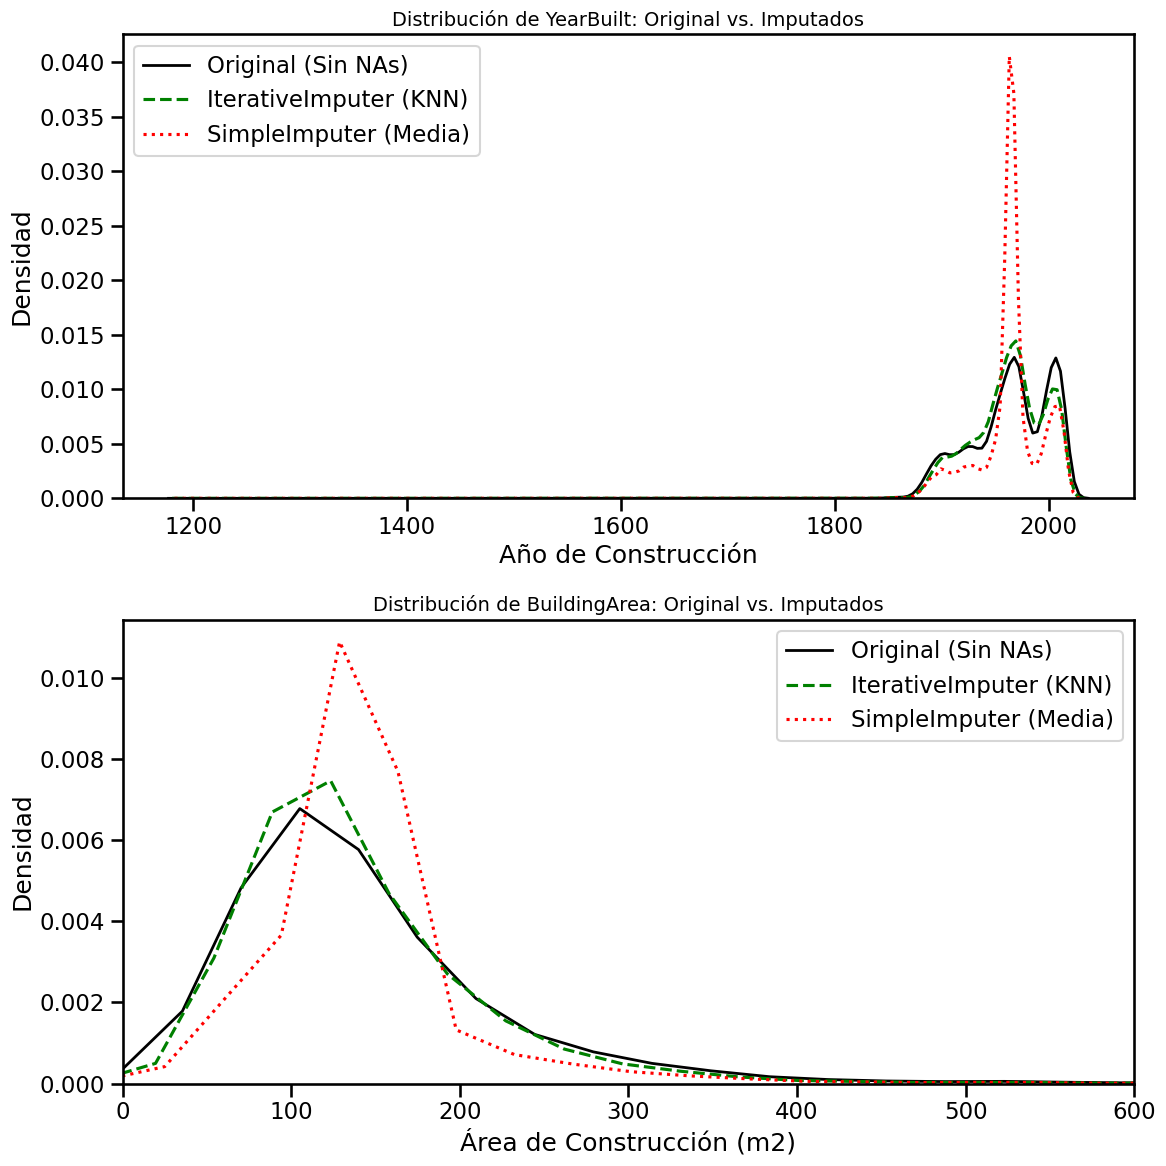

In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

# --- 1. Agregar YearBuilt y BuildingArea a la matriz ---
# Recuperamos las columnas del DataFrame original usando los índices del df limpio
# para mantener la alineación de las filas.
cols_to_add = melb_df.loc[melb_df_clean.index, ['YearBuilt', 'BuildingArea']].reset_index(drop=True)

# Concatenamos con el df_final obtenido en el Ejercicio 1
df_to_impute = pd.concat([df_final, cols_to_add], axis=1)

# Guardamos los nombres de las columnas para reconstruir el DataFrame luego
column_names = df_to_impute.columns

# --- 2. Escalar los datos ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_to_impute)

# --- 3. Aplicar Imputación ---
# Método A: IterativeImputer con KNeighborsRegressor
knn_estimator = KNeighborsRegressor(n_neighbors=5)
iter_imputer = IterativeImputer(estimator=knn_estimator, random_state=42)
X_imputed_knn_scaled = iter_imputer.fit_transform(X_scaled)

# Método B: SimpleImputer (Media) para poder comparar "ambos métodos"
mean_imputer = SimpleImputer(strategy='mean')
X_imputed_mean_scaled = mean_imputer.fit_transform(X_scaled)

# --- 4. Desescalar los datos para poder graficarlos en su escala original ---
X_imputed_knn = scaler.inverse_transform(X_imputed_knn_scaled)
X_imputed_mean = scaler.inverse_transform(X_imputed_mean_scaled)

df_imputed_knn = pd.DataFrame(X_imputed_knn, columns=column_names)
df_imputed_mean = pd.DataFrame(X_imputed_mean, columns=column_names)

# --- 5. Graficar las distribuciones ---
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# Gráfico para YearBuilt
sns.kdeplot(df_to_impute['YearBuilt'].dropna(), label='Original (Sin NAs)', ax=axes[0], color='black', linewidth=2)
sns.kdeplot(df_imputed_knn['YearBuilt'], label='IterativeImputer (KNN)', ax=axes[0], color='green', linestyle='--')
sns.kdeplot(df_imputed_mean['YearBuilt'], label='SimpleImputer (Media)', ax=axes[0], color='red', linestyle=':')
axes[0].set_title('Distribución de YearBuilt: Original vs. Imputados', fontsize=14)
axes[0].set_xlabel('Año de Construcción')
axes[0].set_ylabel('Densidad')
axes[0].legend()

# Gráfico para BuildingArea
sns.kdeplot(df_to_impute['BuildingArea'].dropna(), label='Original (Sin NAs)', ax=axes[1], color='black', linewidth=2)
sns.kdeplot(df_imputed_knn['BuildingArea'], label='IterativeImputer (KNN)', ax=axes[1], color='green', linestyle='--')
sns.kdeplot(df_imputed_mean['BuildingArea'], label='SimpleImputer (Media)', ax=axes[1], color='red', linestyle=':')
axes[1].set_title('Distribución de BuildingArea: Original vs. Imputados', fontsize=14)
axes[1].set_xlabel('Área de Construcción (m2)')
axes[1].set_ylabel('Densidad')
axes[1].set_xlim(0, 600) # Recortamos el eje X para evitar que outliers aplasten la curva
axes[1].legend()

plt.tight_layout()
plt.show()

# Actualizamos nuestra variable para usar en los siguientes ejercicios (ej. PCA)
X_imputed = X_imputed_knn

## Ejercicio 3: Reducción de dimensionalidad.

Utilizando la matriz obtenida en el ejercicio anterior:
1. Aplique `PCA` para obtener $n$ componentes principales de la matriz, donde `n = min(20, X.shape[0])`. ¿Es necesario estandarizar o escalar los datos? Puede decidir si hacer PCA sobre todas las variables o bien seleccionar un subconjunto que crea pertinente.

2. Seleccione las proyecciones de los datos sobre las dos primeras componentes principales (las primeras dos columnas del resultado) para agregar como nuevas características al conjunto de datos.

1. ¿Es necesario estandarizar o escalar los datos?
Sí, es fundamental. El estimador seleccionado para el IterativeImputer es KNeighborsRegressor (KNN). Este algoritmo basa sus predicciones en la distancia (generalmente euclidiana) entre los puntos de datos.

Si los datos no se escalan:

Variables con rangos numéricos grandes (como YearBuilt que ronda los 1900-2000 o Landsize) dominarán la métrica de distancia sobre variables con rangos pequeños (como Rooms o Bathroom).

Esto causaría que el imputador "ignore" las variables con escalas menores, resultando en una imputación sesgada y poco precisa.

Se recomienda utilizar StandardScaler o MinMaxScaler antes de aplicar el imputador.

In [43]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# 1. Estandarizar los datos antes de aplicar PCA
scaler = StandardScaler()
# Asumiendo que 'X_imputed' es tu matriz resultante del Ejercicio 2
X_scaled = scaler.fit_transform(X_imputed)

# 2. Definir 'n' y aplicar PCA
# Se agrega X_scaled.shape[1] al min() como buena práctica para evitar
# errores si el dataset llegara a tener menos de 20 columnas en total.
n_components = min(20, X_scaled.shape[0], X_scaled.shape[1])

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# Opcional: Imprimir cuánta varianza explican estas dos primeras componentes
varianza_explicada = pca.explained_variance_ratio_[:2].sum() * 100
print(f"Varianza explicada por las primeras 2 componentes: {varianza_explicada:.2f}%")

# 3. Seleccionar las proyecciones de las dos primeras componentes principales
pca_features = X_pca[:, :2]

# 4. Agregar como nuevas características al conjunto de datos
# Convertimos el array de las 2 componentes en un DataFrame
df_pca = pd.DataFrame(pca_features, columns=['PCA_comp_1', 'PCA_comp_2'])

# Reseteamos los índices del DataFrame original para evitar desalineaciones al concatenar
df_final = df_final.reset_index(drop=True)

# Concatenamos horizontalmente (axis=1) para agregar las columnas al final
df_augmented = pd.concat([df_final, df_pca], axis=1)

# Visualizamos el resultado
display(df_augmented.head())

Varianza explicada por las primeras 2 componentes: 26.14%


,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,Lattitude,Longtitude,...,Regionname_Eastern Metropolitan,Regionname_Eastern Victoria,Regionname_Northern Metropolitan,Regionname_Northern Victoria,Regionname_South-Eastern Metropolitan,Regionname_Southern Metropolitan,Regionname_Western Metropolitan,Regionname_Western Victoria,PCA_comp_1,PCA_comp_2
0,2.0,1480000.0,2.5,3067.0,2.0,1.0,1.0,202.0,-37.7996,144.9984,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-0.964272,-1.148209
1,2.0,1035000.0,2.5,3067.0,2.0,1.0,0.0,156.0,-37.8079,144.9934,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-1.466501,-1.146352
2,3.0,1465000.0,2.5,3067.0,3.0,2.0,0.0,134.0,-37.8093,144.9944,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.004898,-1.403464
3,3.0,850000.0,2.5,3067.0,3.0,2.0,1.0,94.0,-37.7969,144.9969,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.071866,-1.211272
4,4.0,1600000.0,2.5,3067.0,3.0,1.0,2.0,120.0,-37.8072,144.9941,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.440586,-0.970735


## Ejercicio 4: Composición del resultado

Transformar nuevamente el conjunto de datos procesado en un `pandas.DataFrame` y guardarlo en un archivo.

Para eso, será necesario recordar el nombre original de cada columna de la matriz, en el orden correcto. Tener en cuenta:
1. El método `OneHotEncoder.get_feature_names` o el atributo `OneHotEncoder.categories_` permiten obtener una lista con los valores de la categoría que le corresponde a cada índice de la matriz.
2. Ninguno de los métodos aplicados intercambia de lugar las columnas o las filas de la matriz.

In [46]:
import pandas as pd

# 1. Recuperar nombres de las variables numéricas
# Reemplaza 'numeric_cols' con tu lista de columnas numéricas del Ejercicio 1
nombres_numericos = list(numeric_cols)

# 2. Recuperar nombres de las variables categóricas codificadas
# Usamos el método recomendado o el atributo categories_ en caso de versiones antiguas
try:
    # Intento con versiones modernas de sklearn
    nombres_categoricos = list(encoder.get_feature_names_out(categorical_cols))
except (AttributeError, ValueError):
    # Alternativa manual construida a partir de encoder.categories_ (como sugiere la ayuda)
    nombres_categoricos = []
    for i, col in enumerate(categorical_cols):
        for categoria in encoder.categories_[i]:
            nombres_categoricos.append(f"{col}_{categoria}")

# 3. Recuperar nombres de las variables imputadas (Ejercicio 2)
nombres_imputados = ['YearBuilt', 'BuildingArea']

# 4. Recuperar nombres de las componentes de PCA (Ejercicio 3)
nombres_pca = ['PCA_comp_1', 'PCA_comp_2']

# --- UNIFICACIÓN DE NOMBRES EN ORDEN ---
# El orden debe ser EXACTAMENTE el mismo en el que concatenaste los arrays (np.hstack) a lo largo del TP.
todas_las_columnas = nombres_numericos + nombres_categoricos + nombres_imputados + nombres_pca

# --- CREACIÓN DEL DATAFRAME ---
# Reemplaza 'X_matriz_final' con el nombre de tu variable que contiene la matriz numpy definitiva
df_procesado = pd.DataFrame(X_matriz_final, columns=todas_las_columnas)

# --- GUARDAR EN ARCHIVO ---
# Se guarda como CSV sin incluir el índice para no generar una columna extra
nombre_archivo = 'melb_data_procesado.csv'
df_procesado.to_csv(nombre_archivo, index=False)

print(f"El DataFrame se ha reconstruido con {df_procesado.shape[1]} columnas y {df_procesado.shape[0]} filas.")
print(f"Archivo guardado exitosamente como: '{nombre_archivo}'")

# Mostrar las primeras filas para verificar
display(df_procesado.head())

NameError: name 'X_matriz_final' is not defined

## Ejercicio 5: Documentación

En un documento `.pdf` o `.md` realizar un reporte de las operaciones que realizaron para obtener el conjunto de datos final. Se debe incluir:
  1. Criterios de exclusión (o inclusión) de filas o columnas
  2. Interpretación de las columnas presentes
  2. Todas las transofrmaciones realizadas

Este documento es de uso técnico exclusivamente, y su objetivo es permitir que otres desarrolladores puedan reproducir los mismos pasos y obtener el mismo resultado. Debe ser detallado pero consiso. Por ejemplo:

```
  ## Criterios de exclusión de ejemplos
  1. Se eliminan ejemplos donde el año de construcción es previo a 1900

  ## Características seleccionadas
  ### Características categóricas
  1. Type: tipo de propiedad. 3 valores posibles
  2. ...
  Todas las características categóricas fueron codificadas con un
  método OneHotEncoding utilizando como máximo sus 30 valores más
  frecuentes.
  
  ### Características numéricas
  1. Rooms: Cantidad de habitaciones
  2. Distance: Distancia al centro de la ciudad.
  3. airbnb_mean_price: Se agrega el precio promedio diario de
     publicaciones de la plataforma AirBnB en el mismo código
     postal. [Link al repositorio con datos externos].

  ### Transformaciones:
  1. Todas las características numéricas fueron estandarizadas.
  2. La columna `Suburb` fue imputada utilizando el método ...
  3. Las columnas `YearBuilt` y ... fueron imputadas utilizando el
     algoritmo ...
  4. ...

  ### Datos aumentados
  1. Se agregan las 5 primeras columnas obtenidas a través del
     método de PCA, aplicado sobre el conjunto de datos
     totalmente procesado.
```
